In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation

Import data:

In [2]:
smoke_csv = "./10km_grid/smokePM2pt5_predictions_daily_10km_20060101-20201231.csv"
smoke = pd.read_csv(smoke_csv)
smoke['date'] = pd.to_datetime(smoke['date'], format="%Y%m%d")
smoke.iloc[:5,:]

,grid_id_10km,date,smokePM_pred
0,56334,2006-01-01,2.709746
1,56335,2006-01-01,3.067258
2,56336,2006-01-01,2.482192
3,56337,2006-01-01,3.093114
4,56338,2006-01-01,3.667933


Filter the date:

In [6]:
smoke_2020 = smoke[(smoke['date'] >= "2020-08-01") & (smoke['date'] <= "2020-09-30")]
smoke_2020.iloc[:5,:]

,grid_id_10km,date,smokePM_pred
46997264,38438,2020-08-01,2.459065
46997265,38439,2020-08-01,2.374383
46997266,38440,2020-08-01,2.738663
46997267,38441,2020-08-01,2.587327
46997268,38442,2020-08-01,4.757607


Load the grid shapefile:

In [9]:
grid_shp = "./10km_grid/10km_grid_wgs84/10km_grid_wgs84.shp"
grid = gpd.read_file(grid_shp)

# merge predictions with the grid
grid = grid.merge(smoke_2020, left_on='ID', right_on='grid_id_10km')

# fill Na with 0
grid['smokePM_pred'] = grid['smokePM_pred'].fillna(0)

# convert to a GeoDataFrame
grid = gpd.GeoDataFrame(grid, geometry='geometry', crs=grid.crs)

grid.iloc[:5,:]

,ID,COORDX,COORDY,geometry,grid_id_10km,date,smokePM_pred
0,1397,-800000.0,2770000.0,"POLYGON ((-81.71753 24.54554, -81.70852 24.457...",1397,2020-09-16,4.042009
1,1397,-800000.0,2770000.0,"POLYGON ((-81.71753 24.54554, -81.70852 24.457...",1397,2020-09-17,2.382586
2,1398,-790000.0,2770000.0,"POLYGON ((-81.62121 24.55377, -81.61226 24.465...",1398,2020-09-16,4.013557
3,1398,-790000.0,2770000.0,"POLYGON ((-81.62121 24.55377, -81.61226 24.465...",1398,2020-09-17,2.415151
4,1399,-780000.0,2770000.0,"POLYGON ((-81.52484 24.56195, -81.51596 24.473...",1399,2020-09-16,4.032649


Filter to California:

In [5]:
states = gpd.read_file("./tl_2025_us_state/tl_2025_us_state.shp")
california = states[states["NAME"] == "California"]
california = california.to_crs(grid.crs)
grid_ca = gpd.sjoin(grid, california, how='inner', predicate='intersects')

## Plot one day:

In [6]:
# select date
day = pd.to_datetime("2020-08-01")

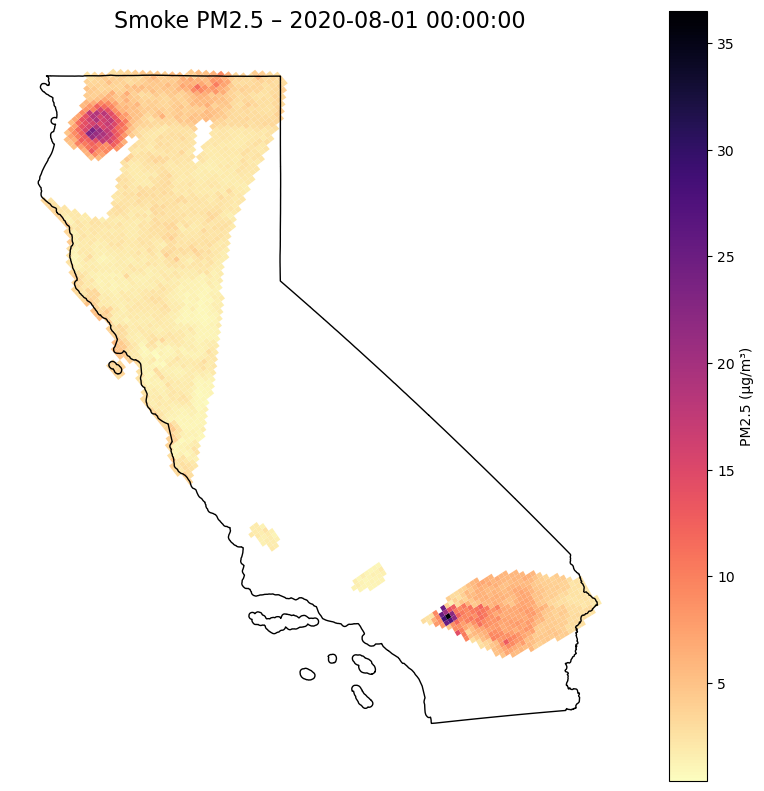

In [7]:
fig, ax = plt.subplots(figsize=(10,10))
california.plot(ax=ax, color='white')
california.boundary.plot(ax=ax, color='black', linewidth=1)

smoke_plot = grid_ca[grid_ca['date'] == day].plot(
    column='smokePM_pred', cmap='magma_r', legend=True, ax=ax,
    legend_kwds={'label': "PM2.5 (µg/m³)"},
    missing_kwds={"color": "black"}
)
title = ax.set_title(f"Smoke PM2.5 – {day}", fontsize=16)
plt.axis('off')
plt.show()

Set up the animation:

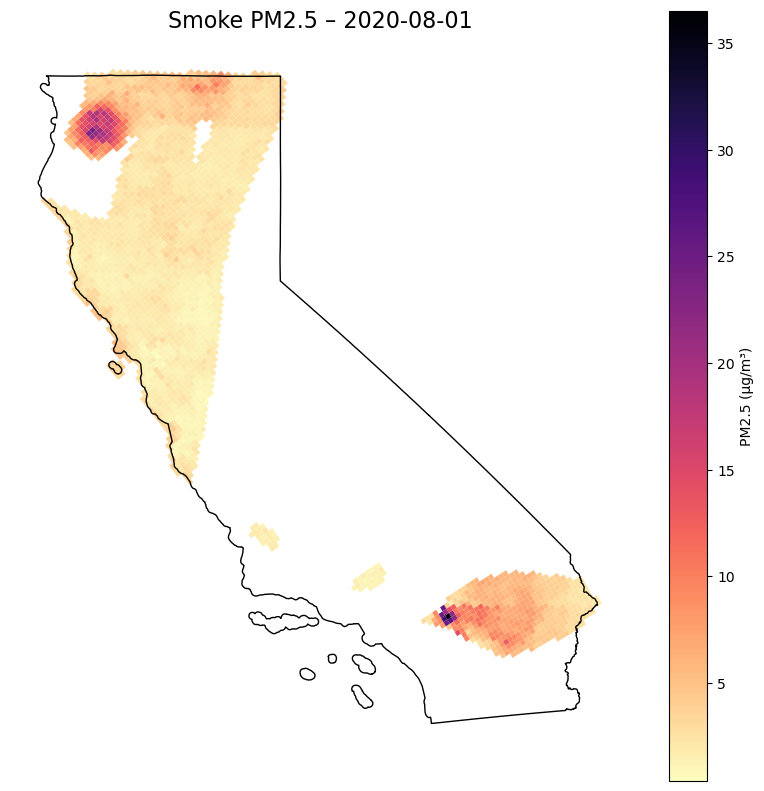

In [8]:
from matplotlib import animation

grid_ca = grid_ca.sort_values('date')
dates = grid_ca['date'].unique()

fig, ax = plt.subplots(figsize=(10,10))

california.plot(ax=ax, color='white')
california.boundary.plot(ax=ax, color='black', linewidth=1)


smoke_plot = grid_ca[grid_ca['date'] == dates[0]].plot(
    column='smokePM_pred', cmap='magma_r', legend=True, ax=ax,
    legend_kwds={'label': "PM2.5 (µg/m³)"}
)
title = ax.set_title(f"Smoke PM2.5 – {dates[0].date()}", fontsize=16)

# Function to update each frame
def update(i):
    ax.clear()
    california.plot(ax=ax, color='white')
    california.boundary.plot(ax=ax, color='black', linewidth=1)
    grid_day = grid_ca[grid_ca['date'] == dates[i]]
    grid_day.plot(
        column='smokePM_pred', cmap='magma_r', legend=False, ax=ax,
        legend_kwds={'label': "PM2.5 (µg/m³)"}
    )
    ax.set_title(f"Smoke PM2.5 – {dates[i].date()}", fontsize=16)
    ax.axis('off')

anim = FuncAnimation(fig, update, frames=len(dates), interval=300)

## Animation of the entire date range

In [9]:
from IPython.display import HTML
HTML(anim.to_html5_video())